# Constructing a Spatial Firing-Rate Map

In this tutorial, we will construct a spatial firing-rate map from position and spike data.

The basic idea is: $ R(x,y) = \frac{N(x,y)}{T(x,y)}$

where:

- $N(x,y)$ is the number of spikes observed in spatial bin $(x,y)$
- $T(x,y)$ is the amount of time the animal spent in spatial bin $(x,y)$
- $R(x,y)$ is the estimated firing rate in Hz

The analysis consists of four main steps:

1. Convert the tracking coordinates into physical spatial coordinates.
2. Divide the environment into spatial bins.
3. Calculate occupancy and spike counts for each bin.
4. Divide spike count by occupancy to obtain the firing-rate map.

![Dimensions-of-6-different-scales](6-arenas.png)

## 1. Import the required libraries

We will use:

- `pandas` to load and manipulate the position and spike data
- `numpy` for numerical calculations
- `matplotlib` for visualization

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

Matplotlib is building the font cache; this may take a moment.


## 2. Load the position and spike data

The position file contains the animal's position at each timestamp:

| timestamp | x | y |
|---|---:|---:|
| ... | ... | ... |

The spike file contains the number of spikes recorded at the corresponding timestamps:

| timestamp | spike_count |
|---|---:|
| ... | ... |

The two files must correspond to the same recording.

In [6]:
positions_file = "C11Day11TT2cl4sPositions.tsv"
spikes_file = "C11Day11TT2cl4Spikes.tsv"

positions = pd.read_csv(positions_file, sep="\t")
spikes = pd.read_csv(spikes_file, sep="\t")

## 3. Inspect the input data

Before calculating the rate map, we inspect the structure of the data and the spatial and temporal ranges.

The position and spike data should have the same number of samples and corresponding timestamps.

In [7]:
print("Position samples:", len(positions))
print("Spike samples:", len(spikes))
print("Total spikes:", spikes["spike_count"].sum())

print("\nPosition columns:")
print(positions.columns.tolist())

print("\nSpike columns:")
print(spikes.columns.tolist())

print("\nPosition range:")
print(f"X: {positions['x'].min():.3f} to {positions['x'].max():.3f}")
print(f"Y: {positions['y'].min():.3f} to {positions['y'].max():.3f}")

print("\nMissing values:")
print(positions.isna().sum())
print(spikes.isna().sum())

Position samples: 27140
Spike samples: 27140
Total spikes: 2881

Position columns:
['timestamp', 'x', 'y']

Spike columns:
['timestamp', 'spike_count']

Position range:
X: 156.058 to 458.928
Y: 78.083 to 374.967

Missing values:
timestamp    0
x            0
y            0
dtype: int64
timestamp      0
spike_count    0
dtype: int64


## 4. Define the environment

The physical dimensions of the environment are specified here.

Only these parameters need to be changed when analysing a different environment:

- `environment_width_cm`: width of the environment
- `environment_height_cm`: height of the environment
- `bin_size_cm`: width and height of each spatial bin

For example, a 100 × 100 cm environment with 5 × 5 cm bins produces: $100/5 = 20$ bins along both X and Y axes.

The resulting rate map therefore has shape: $20 \times 20$

In [8]:
environment_width_cm = 100
environment_height_cm = 100

bin_size_cm = 5

## 5. Convert tracking coordinates to centimetres

The tracking system provides X and Y coordinates in its own coordinate system.

We map these coordinates onto the physical dimensions of the environment.

The minimum observed coordinate is mapped to 0 cm and the maximum observed coordinate is mapped to the corresponding physical environment boundary.

For X: $$x_{cm} = \frac{x-x_{min}}{x_{max}-x_{min}} \times W$$

For Y: $$y_{cm} = \frac{y-y_{min}}{y_{max}-y_{min}} \times H$$

where $W$ and $H$ are the physical width and height of the environment.

In [9]:
x = positions["x"].to_numpy()
y = positions["y"].to_numpy()

x_cm = (x - x.min()) * environment_width_cm / (x.max() - x.min())
y_cm = (y - y.min()) * environment_height_cm / (y.max() - y.min())

## 6. Divide the environment into spatial bins

The environment is divided into equally sized square spatial bins.

For a bin size of 5 cm:

$$5 \times 5\text{ cm}$$

Each position sample is assigned to one spatial bin.

The number of bins is determined automatically from the environment dimensions:

$$N_x = \frac{W}{\text{bin size}}$$

$$N_y = \frac{H}{\text{bin size}}$$

The X and Y dimensions are handled independently, so rectangular environments are supported.

In [10]:
x_edges = np.arange(0, environment_width_cm + bin_size_cm, bin_size_cm)
y_edges = np.arange(0, environment_height_cm + bin_size_cm, bin_size_cm)

n_x = len(x_edges) - 1
n_y = len(y_edges) - 1

x_bin = np.clip(np.digitize(x_cm, x_edges) - 1, 0, n_x - 1)
y_bin = np.clip(np.digitize(y_cm, y_edges) - 1, 0, n_y - 1)

print(f"Spatial bins: {n_y} × {n_x}")

Spatial bins: 20 × 20


## 7. Visualize the animal's trajectory

Before calculating the rate map, we can visualize the trajectory in physical coordinates.

The axes are now expressed in centimetres rather than tracking-system pixels.

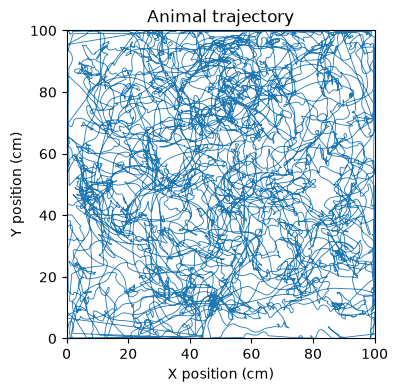

In [11]:
plt.figure(figsize=(4, 4))

plt.plot(x_cm, y_cm, linewidth=0.6)

plt.xlim(0, environment_width_cm)
plt.ylim(0, environment_height_cm)
plt.gca().set_aspect("equal")

plt.xlabel("X position (cm)")
plt.ylabel("Y position (cm)")
plt.title("Animal trajectory")

plt.show()

## 8. Calculate occupancy

Occupancy is the amount of time the animal spends in each spatial bin.

For consecutive position samples:

$$
\Delta t_i = t_{i+1}-t_i
$$

The timestamps are in microseconds, so we convert the interval to seconds:

$$
\Delta t_i =
\frac{t_{i+1}-t_i}{10^6}
$$

Each time interval is assigned to the spatial bin containing the corresponding position.

The result is an occupancy map:

$$
T(x,y)
$$

where each element contains the amount of time spent in that spatial bin.

In [12]:
timestamp = positions["timestamp"].to_numpy()

dt = np.diff(timestamp) / 1e6

occupancy = np.zeros((n_y, n_x))

for i in range(len(dt)):
    occupancy[y_bin[i], x_bin[i]] += dt[i]

## 9. Visualize occupancy

The occupancy map shows where the animal spent time during the recording.

Bins with little or no occupancy will provide poor estimates of firing rate.

## 10. Calculate spike counts in each spatial bin

We now introduce the neural data.

At each timestamp, `spike_count` tells us how many spikes occurred.

Each spike count is assigned to the spatial bin occupied by the animal at that timestamp.

This produces the spatial spike-count map:

$$
N(x,y)
$$

where each bin contains the total number of spikes observed while the animal was in that location.

In [13]:
spike_counts = spikes["spike_count"].to_numpy()

spike_count_map = np.zeros((n_y, n_x))

for i in range(len(positions)):
    if spike_counts[i] > 0:
        spike_count_map[y_bin[i], x_bin[i]] += spike_counts[i]

## 11. Calculate the spatial firing-rate map

We now have the two quantities required to calculate firing rate:

$$
N(x,y) = \text{spike count}
$$

and

$$
T(x,y) = \text{occupancy time}
$$

Therefore:

$$
R(x,y)=\frac{N(x,y)}{T(x,y)}
$$

The resulting firing rate is measured in spikes per second, or Hz.

Bins with zero occupancy cannot provide a firing-rate estimate, so these bins are represented as `NaN`.

In [14]:
rate_map = np.full_like(occupancy, np.nan)

occupied = occupancy > 0

rate_map[occupied] = (
    spike_count_map[occupied] /
    occupancy[occupied]
)

## 12. Visualize the trajectory, occupancy, and firing-rate map

The three main spatial views are shown together:

1. **Animal trajectory**: where the animal moved.
2. **Occupancy map**: how much time was spent at each location.
3. **Firing-rate map**: the estimated firing rate at each location.

Keeping the same physical coordinate system and aspect ratio makes the spatial structure directly comparable across panels.

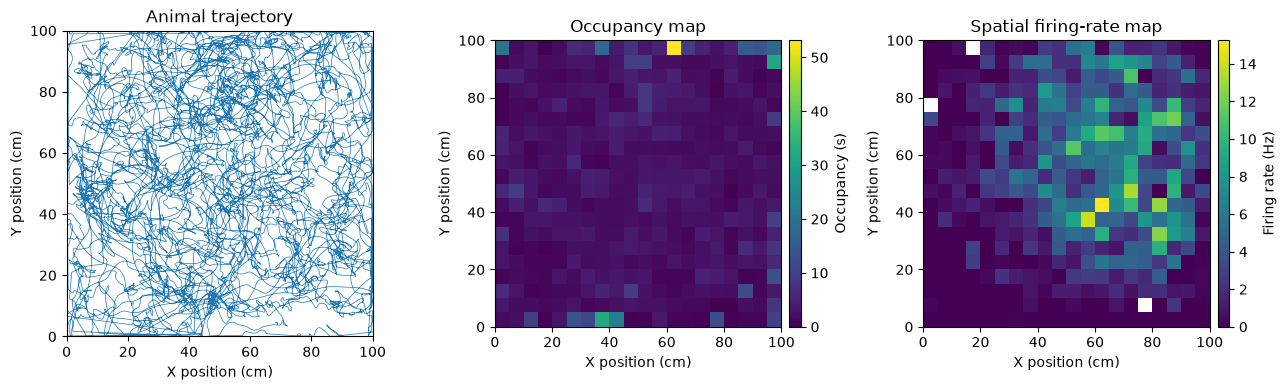

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=False)
fig.subplots_adjust(wspace=0.4)

# 1. Trajectory
axes[0].plot(x_cm, y_cm, linewidth=0.5)
axes[0].set_xlim(0, environment_width_cm)
axes[0].set_ylim(0, environment_height_cm)
axes[0].set_aspect("equal")
axes[0].set_xlabel("X position (cm)")
axes[0].set_ylabel("Y position (cm)")
axes[0].set_title("Animal trajectory")

# 2. Occupancy
im1 = axes[1].imshow(
    occupancy,
    origin="lower",
    extent=[0, environment_width_cm, 0, environment_height_cm],
    aspect="equal"
)
axes[1].set_xlabel("X position (cm)")
axes[1].set_ylabel("Y position (cm)")
axes[1].set_title("Occupancy map")
divider = make_axes_locatable(axes[1])
cax1 = divider.append_axes("right", size="4%", pad=0.08)
fig.colorbar(im1, cax=cax1, label="Occupancy (s)")

# 3. Firing rate
im2 = axes[2].imshow(
    rate_map,
    origin="lower",
    extent=[0, environment_width_cm, 0, environment_height_cm],
    aspect="equal"
)
axes[2].set_xlabel("X position (cm)")
axes[2].set_ylabel("Y position (cm)")
axes[2].set_title("Spatial firing-rate map")
divider = make_axes_locatable(axes[2])
cax2 = divider.append_axes("right", size="4%", pad=0.08)
fig.colorbar(im2, cax=cax2, label="Firing rate (Hz)")

plt.show()

## 14. Inspect firing-rate statistics

Two simple quantities are useful for describing the firing-rate map:

- Mean firing rate: total spikes divided by total recording time
- Peak firing rate: maximum value in the spatial firing-rate map

The mean firing rate is calculated from the complete recording rather than by averaging the individual spatial bins.

In [16]:
total_spikes = spike_count_map.sum()
total_time = occupancy.sum()

mean_firing_rate = total_spikes / total_time
peak_firing_rate = np.nanmax(rate_map)

print(f"Mean firing rate: {mean_firing_rate:.3f} Hz")
print(f"Peak firing rate: {peak_firing_rate:.3f} Hz")

Mean firing rate: 2.214 Hz
Peak firing rate: 15.254 Hz


## Bonus: Gaussian smoothing

The raw firing-rate map can contain sharp bin-to-bin fluctuations, especially when some spatial bins contain relatively few samples or spikes.

Gaussian smoothing replaces each bin with a weighted average of neighbouring bins. Nearby bins receive larger weights than distant bins.

The parameter `sigma` controls the width of the Gaussian kernel, in units of spatial bins. A larger `sigma` produces a smoother map and spreads spatial structure over a larger distance.

For a physically interpretable smoothing scale, remember that:

$$
\text{smoothing width in cm} \approx \sigma \times \text{bin size in cm}
$$

Here we smooth the **spike-count map and occupancy map separately**, then divide them. This preserves the interpretation of the rate map as spike count divided by occupancy.

In [17]:
from scipy.ndimage import gaussian_filter

# Gaussian width in spatial bins
sigma = 1

# Smooth spike counts and occupancy separately
spike_count_smooth = gaussian_filter(spike_count_map, sigma=sigma)
occupancy_smooth = gaussian_filter(occupancy, sigma=sigma)

# Calculate smoothed firing rate
rate_map_smooth = np.full_like(occupancy_smooth, np.nan)

occupied_smooth = occupancy_smooth > 0
rate_map_smooth[occupied_smooth] = (
    spike_count_smooth[occupied_smooth] /
    occupancy_smooth[occupied_smooth]
)


### Compare raw and smoothed rate maps

The raw map preserves the original bin-level estimates. The smoothed map emphasizes broader spatial structure while reducing local fluctuations.

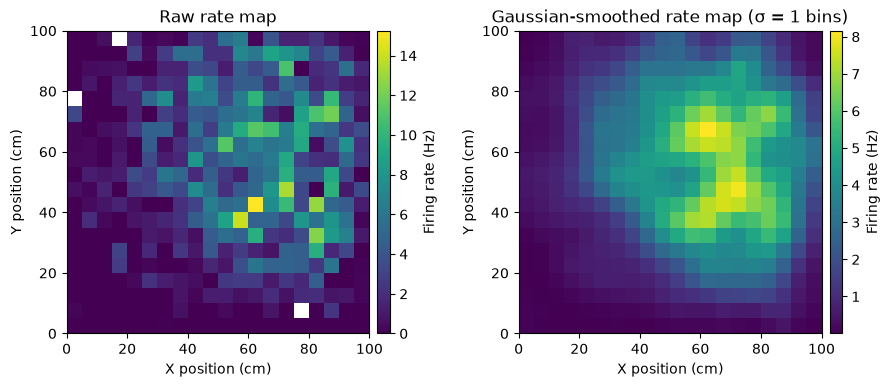

In [18]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=False)
fig.subplots_adjust(wspace=0.4)

im1 = axes[0].imshow(
    rate_map,
    origin="lower",
    extent=[0, environment_width_cm, 0, environment_height_cm],
    aspect="equal"
)
axes[0].set_xlabel("X position (cm)")
axes[0].set_ylabel("Y position (cm)")
axes[0].set_title("Raw rate map")
divider = make_axes_locatable(axes[0])
cax1 = divider.append_axes("right", size="4%", pad=0.08)
fig.colorbar(im1, cax=cax1, label="Firing rate (Hz)")

im2 = axes[1].imshow(
    rate_map_smooth,
    origin="lower",
    extent=[0, environment_width_cm, 0, environment_height_cm],
    aspect="equal"
)
axes[1].set_xlabel("X position (cm)")
axes[1].set_ylabel("Y position (cm)")
axes[1].set_title(f"Gaussian-smoothed rate map (σ = {sigma} bins)")
divider = make_axes_locatable(axes[1])
cax2 = divider.append_axes("right", size="4%", pad=0.08)
fig.colorbar(im2, cax=cax2, label="Firing rate (Hz)")

plt.show()

## 15. What did we calculate?

The complete analysis can be summarized as:

**Position data**

$$
(x_t,y_t)
$$

↓

**Convert tracking coordinates to physical coordinates**

$$
(x_t,y_t) \rightarrow (x_{cm},y_{cm})
$$

↓

**Divide the environment into spatial bins**

↓

**Calculate occupancy**

$$
T(x,y)
$$

↓

**Assign spikes to spatial bins**

↓

**Calculate spike counts**

$$
N(x,y)
$$

↓

**Divide spike count by occupancy**

$$
R(x,y)=\frac{N(x,y)}{T(x,y)}
$$

↓

**Spatial firing-rate map**

The resulting map represents the neuron's estimated firing rate as a function of the animal's location.

No spatial smoothing has been applied.

[ 1.  1.  2.  1. 10.  0.  3.  2.  2.]
[1.05962746 1.2818582  1.88069942 3.37472088 4.51505885 3.32573111
 2.34249774 2.16944408 2.05036225]


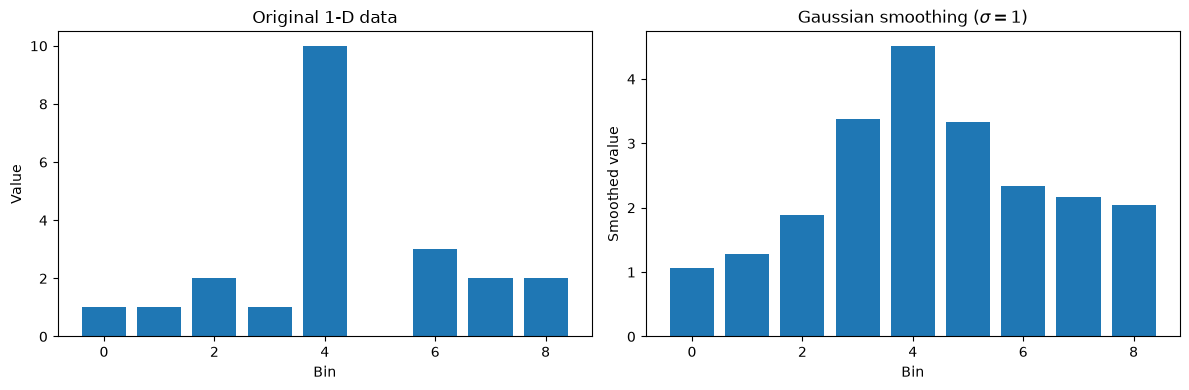

[[ 1  1  2  1  0]
 [ 1  2  3  2  1]
 [ 0  2 10  3  1]
 [ 1  1  2  2  0]
 [ 0  1  1  0  0]]
[[0 0 1 0 0]
 [0 1 2 1 0]
 [0 1 2 2 0]
 [0 1 1 1 0]
 [0 0 0 0 0]]


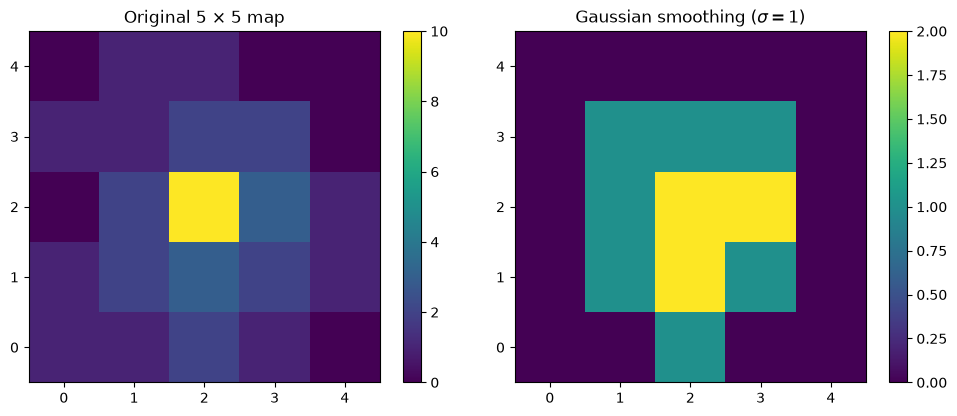

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, gaussian_filter1d

# -------------------------
# 1-D example
# -------------------------
x = np.array([1.0, 1.0, 2.0, 1.0, 10.0, 0.0, 3.0, 2.0, 2.0])
x_smooth = gaussian_filter1d(x, sigma=1)
print(x)
print(x_smooth)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(np.arange(9), x)
ax[0].set_title("Original 1-D data")
ax[0].set_xlabel("Bin")
ax[0].set_ylabel("Value")

ax[1].bar(np.arange(9), x_smooth)
ax[1].set_title("Gaussian smoothing ($\\sigma=1$)")
ax[1].set_xlabel("Bin")
ax[1].set_ylabel("Smoothed value")

plt.tight_layout()
plt.show()


# -------------------------
# 2-D example
# -------------------------
data = np.array([
    [1, 1, 2, 1, 0],
    [1, 2, 3, 2, 1],
    [0, 2, 10, 3, 1],
    [1, 1, 2, 2, 0],
    [0, 1, 1, 0, 0]
])

data_smooth = gaussian_filter(data, sigma=1)
print(data)
print(data_smooth)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax[0].imshow(data, origin="lower")
ax[0].set_title("Original 5 × 5 map")
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(data_smooth, origin="lower")
ax[1].set_title("Gaussian smoothing ($\\sigma=1$)")
plt.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import plotly.graph_objects as go

# Load ONLY the spikes file
spikes = pd.read_csv("C11Day11TT2cl4Spikes.tsv", sep="\t")

# Inspect columns once
print(spikes.columns)
print(spikes.head())

Index(['timestamp', 'spike_count'], dtype='str')
      timestamp  spike_count
0  1.066417e+10            0
1  1.066421e+10            0
2  1.066424e+10            0
3  1.066427e+10            0
4  1.066431e+10            0


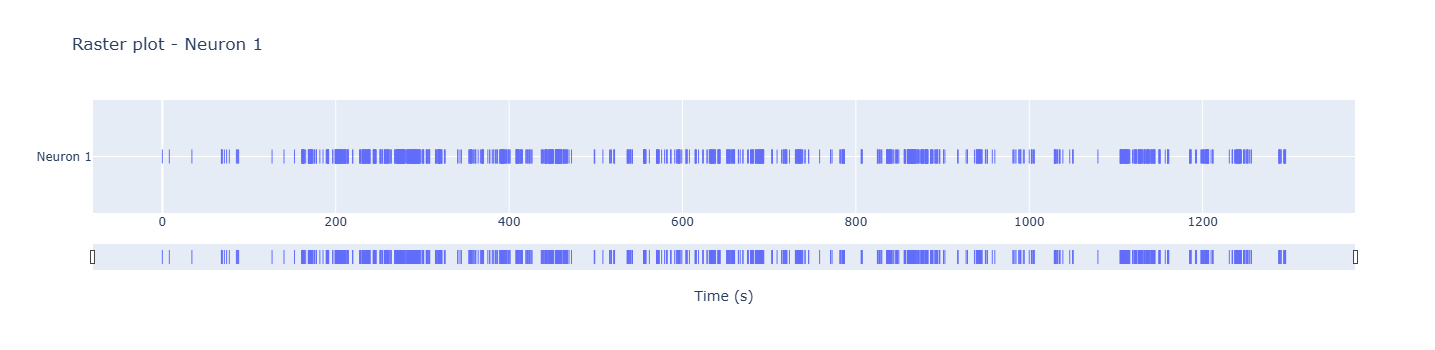

In [4]:
import numpy as np
import plotly.graph_objects as go

# Change these two names if your TSV uses different column names
time_col = "timestamp"
neuron_col = "spike_count"

# Select one neuron
neuron = 1
spikes_n = spikes[spikes[neuron_col] == neuron].copy()

# Convert timestamp differences from microseconds → seconds
# First timestamp becomes t = 0
spikes_n["time_s"] = (
    spikes_n[time_col] - spikes_n[time_col].iloc[0]
) / 1e6

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=spikes_n["time_s"],
        y=[1] * len(spikes_n),
        mode="markers",
        marker=dict(
            symbol="line-ns-open",
            size=10
        ),
        hovertemplate="Time: %{x:.3f} s<extra></extra>",
        name=f"Neuron {neuron}"
    )
)

fig.update_layout(
    title=f"Raster plot - Neuron {neuron}",
    xaxis=dict(
        title="Time (s)",
        rangeslider=dict(visible=True),
        type="linear"
    ),
    yaxis=dict(
        title="",
        tickvals=[1],
        ticktext=[f"Neuron {neuron}"],
        range=[0.5, 1.5]
    ),
    height=350,
    showlegend=False
)

fig.show()